# Hierarchical analysis of hourly values

Johannes Zauner

## Preface

This script uses hierarchical generalized additive model to explore the following hypothesis:

> Personal light exposure patterns depend on wearing position

*Type of model:* HGAM (Hierarchical GAM)

*Base formula:* $\text{melanopic EDI} \sim  s(\text{Time}) + s(\text{Time}, \text{position}) + s(\text{Time}, \text{Site}) + s(\text{Time}, \text{Participant})$

*Additional notes:* - position and site effects are modelled with the `sz` basis, that allows for the most identifiable modelling of parametric differences - Participant effects are modelled with the `fs` basis, which models the participant-effects as random smooths - melanopic EDI is scaled with `log_zero_inflated()` before model fitting.

## Setup

In [ ]:
library(tidyverse)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Loading required package: nlme

Attaching package: 'nlme'

The following object is masked from 'package:dplyr':

    collapse

This is mgcv 1.9-4. For overview type '?mgcv'.

here() starts at /Users/zauner/Documents/Arbeit/12-TUM/Repos_Misc/WearingPositionError_2026


Attaching package: 'gratia'

The following object is masked from 'package:stringr':

    boundary

Loading required package: plotfunctions


Attaching package: 'plotfunctions'

The following object is masked from 'package:ggplot2':

    alpha

Loaded package itsadug 2.5 (see 'help("itsadug")' ).

Attaching package: 'itsadug'

The following object is masked from 'package:gratia':

    dispersion


Attaching package: 'cowplot'

The following object is masked from 'package:lubridate':

    stamp


Attaching package: 'gt'

The following object is masked from 'package:cowplot':

    as_gtable

### Preparation

In [ ]:
colors <- ggsci::pal_jco()(3) |> set_names(c("glasses", "chest", "wrist"))
load(here("data/prepared_time_data.RData"))
time_data <- 
  time_data |> 
  mutate(position = fct(position, levels = c("glasses", "chest", "wrist")))


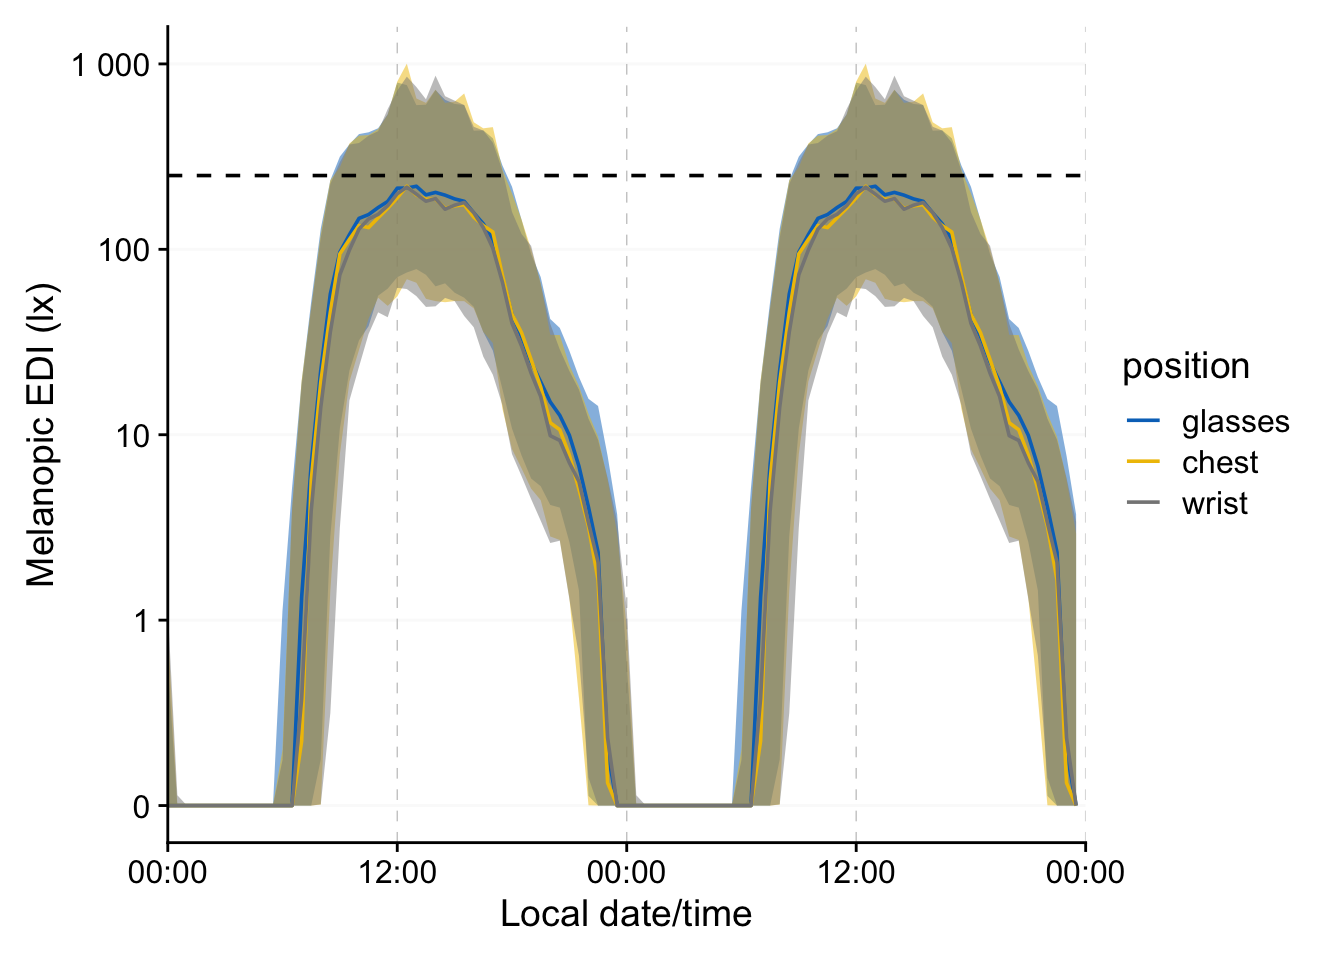

In [ ]:
time_data|>
  group_by(position) |> 
  mutate(position = fct_relevel(position, "glasses")) |> 
  aggregate_Date(
    date.handler = \(x) ymd("2025-01-01"),
    numeric.handler = \(x) median(x, na.rm = TRUE),
    p75 = quantile(MEDI, p=0.75, na.rm = TRUE),
    p25 = quantile(MEDI, p=0.25, na.rm = TRUE)
  ) |> 
  gg_doubleplot(geom = "blank", jco_color = FALSE, facetting = FALSE,
                x.axis.breaks.repeat = ~Datetime_breaks(.x, by = "12 hours", shift =
    lubridate::duration(0, "hours"))) +
  geom_ribbon(aes(ymin = p25, ymax = p75, fill = position), alpha = 0.5) +
  geom_line(aes(color = position)) +
  geom_hline(yintercept = 250, linetype = "dashed") +
  scale_color_jco()+
  scale_fill_jco() +
  guides(fill = "none") +
  theme(panel.spacing = unit(2, "lines"))


In [ ]:
formula_1 <- lzMEDI ~ s(Time, k = 12) + s(Time, position, bs = "fs", k = 12) + s(Time, site, bs = "sz", k = 12) + s(Time, Id, bs = "fs") + s(Id_date, bs = "re")
formula_0 <- lzMEDI ~ s(Time, k = 12) + s(Time, site, bs = "sz", k = 12) + s(Time, Id, bs = "fs") + s(Id_date, bs = "re")


### Analysis

#### Base model

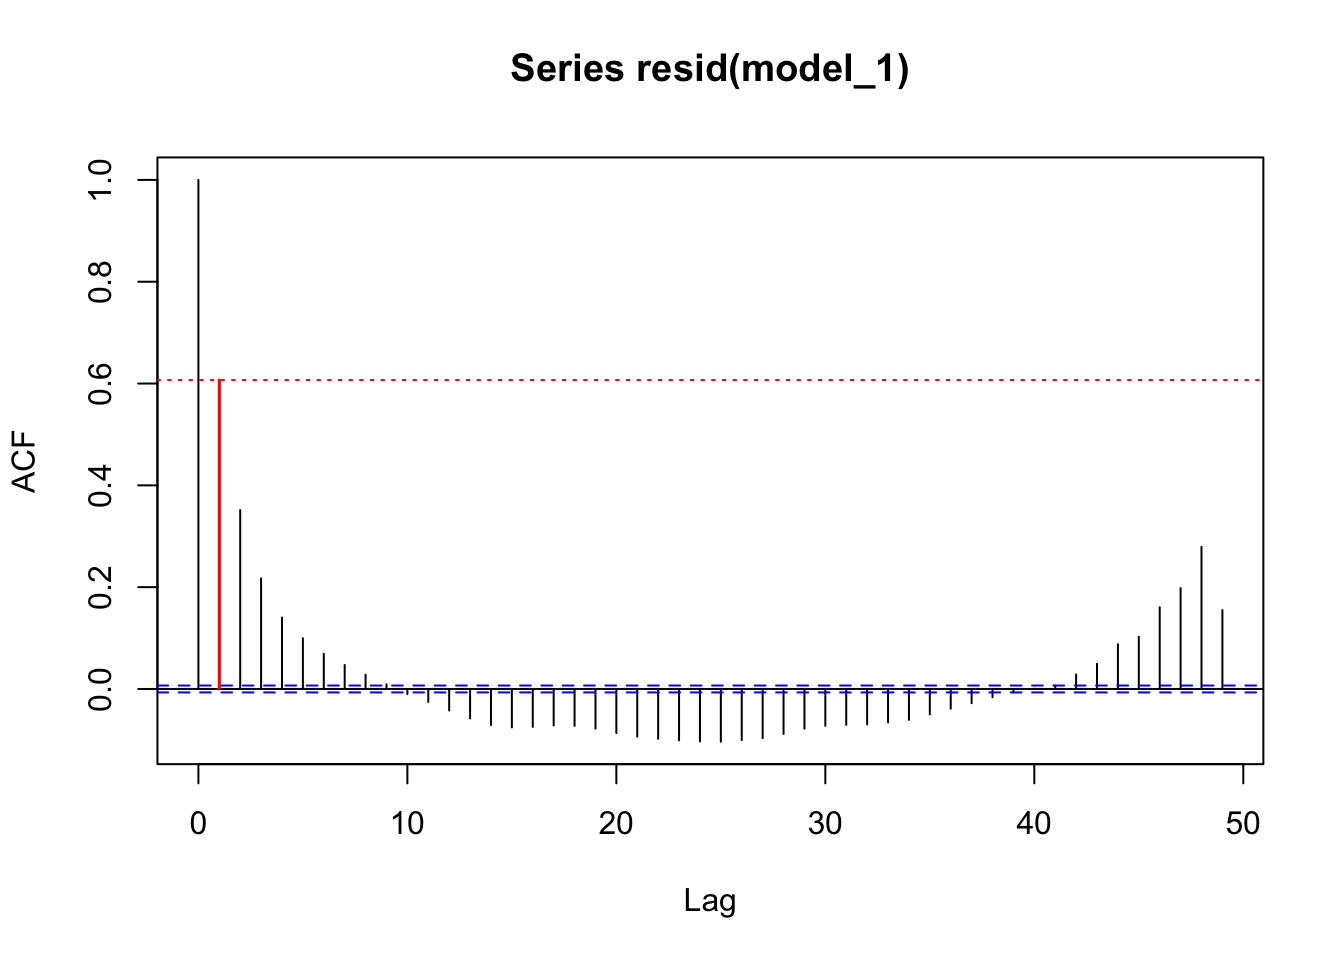

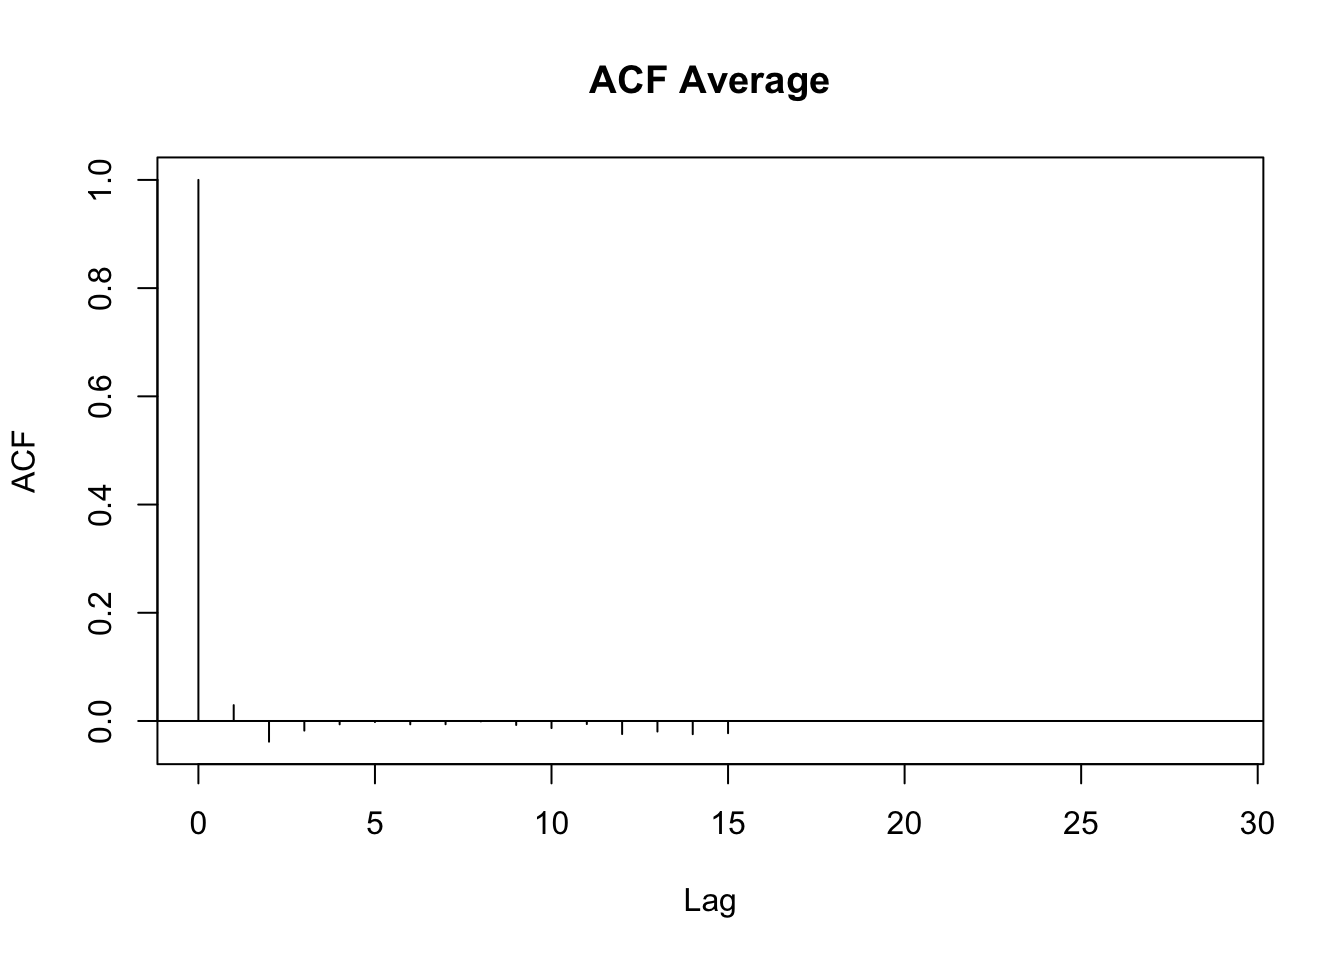


Family: gaussian 
Link function: identity 

Formula:
lzMEDI ~ s(Time, k = 12) + s(Time, position, bs = "fs", k = 12) + 
    s(Time, site, bs = "sz", k = 12) + s(Time, Id, bs = "fs") + 
    s(Id_date, bs = "re")

Parametric coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.84087    0.03369   24.96   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                     edf  Ref.df       F  p-value    
s(Time)           10.830   10.89 196.192  < 2e-16 ***
s(Time,position)   4.354   35.00   0.680 2.44e-05 ***
s(Time,site)      68.461   72.47   5.707  < 2e-16 ***
s(Time,Id)       819.948 1045.00  14.946  < 2e-16 ***
s(Id_date)       415.041  596.00   3.492  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =   0.75   Deviance explained = 75.4%
fREML =  80376  Scale est. = 0.59913   n = 83946

# A tibble: 1 × 9
     df  logLik     AIC     BIC deviance df.residual  nobs adj.r.squared  npar
  <dbl>   <dbl>   <dbl>   <dbl>    <dbl>       <dbl> <int>         <dbl> <int>
1 1320. -77742. 158134. 170507.   50505.      82626. 83946         0.750  1794

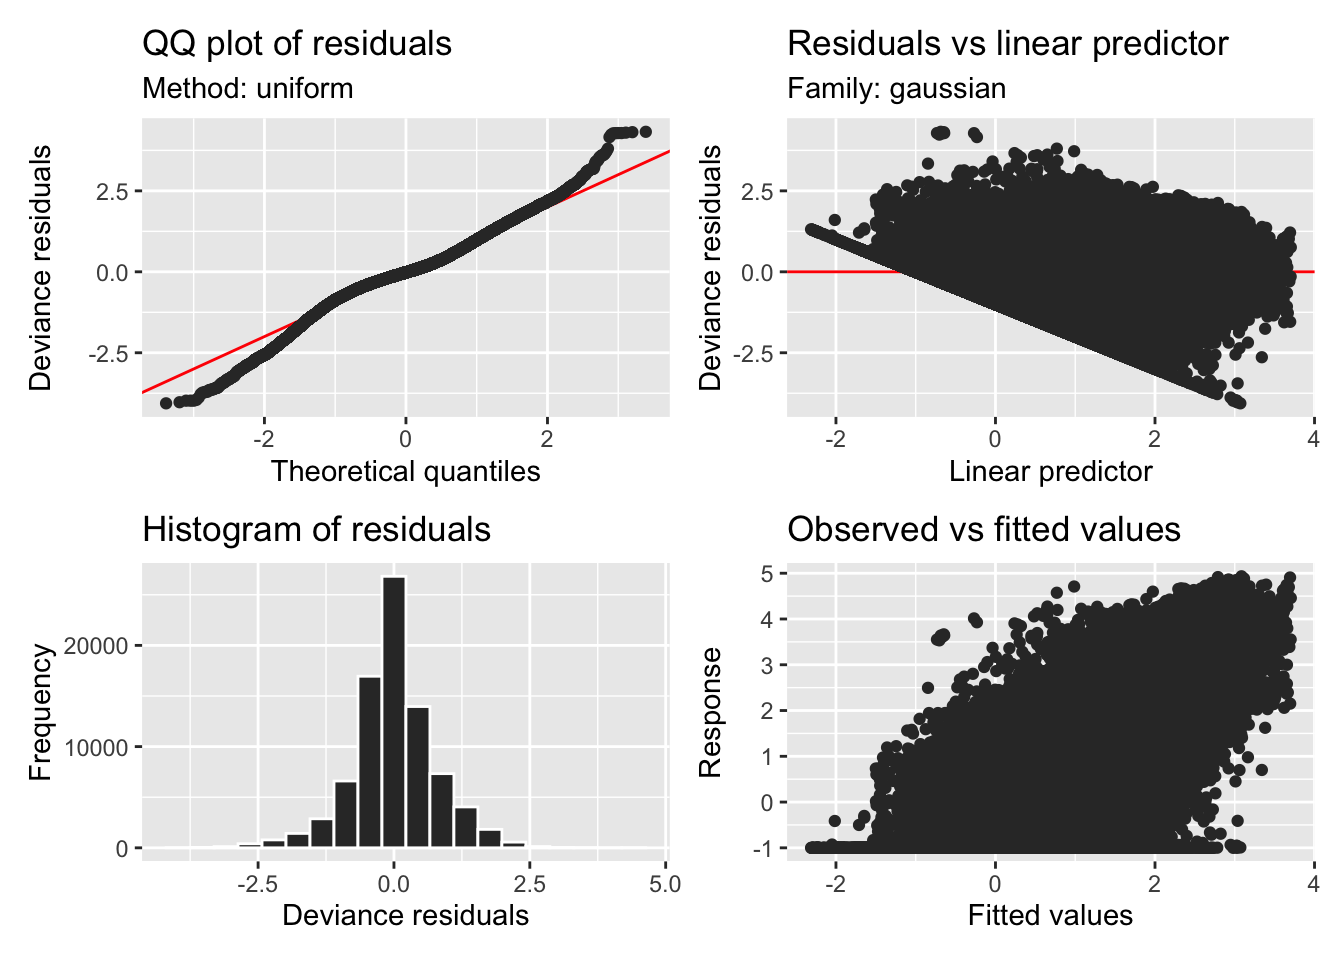

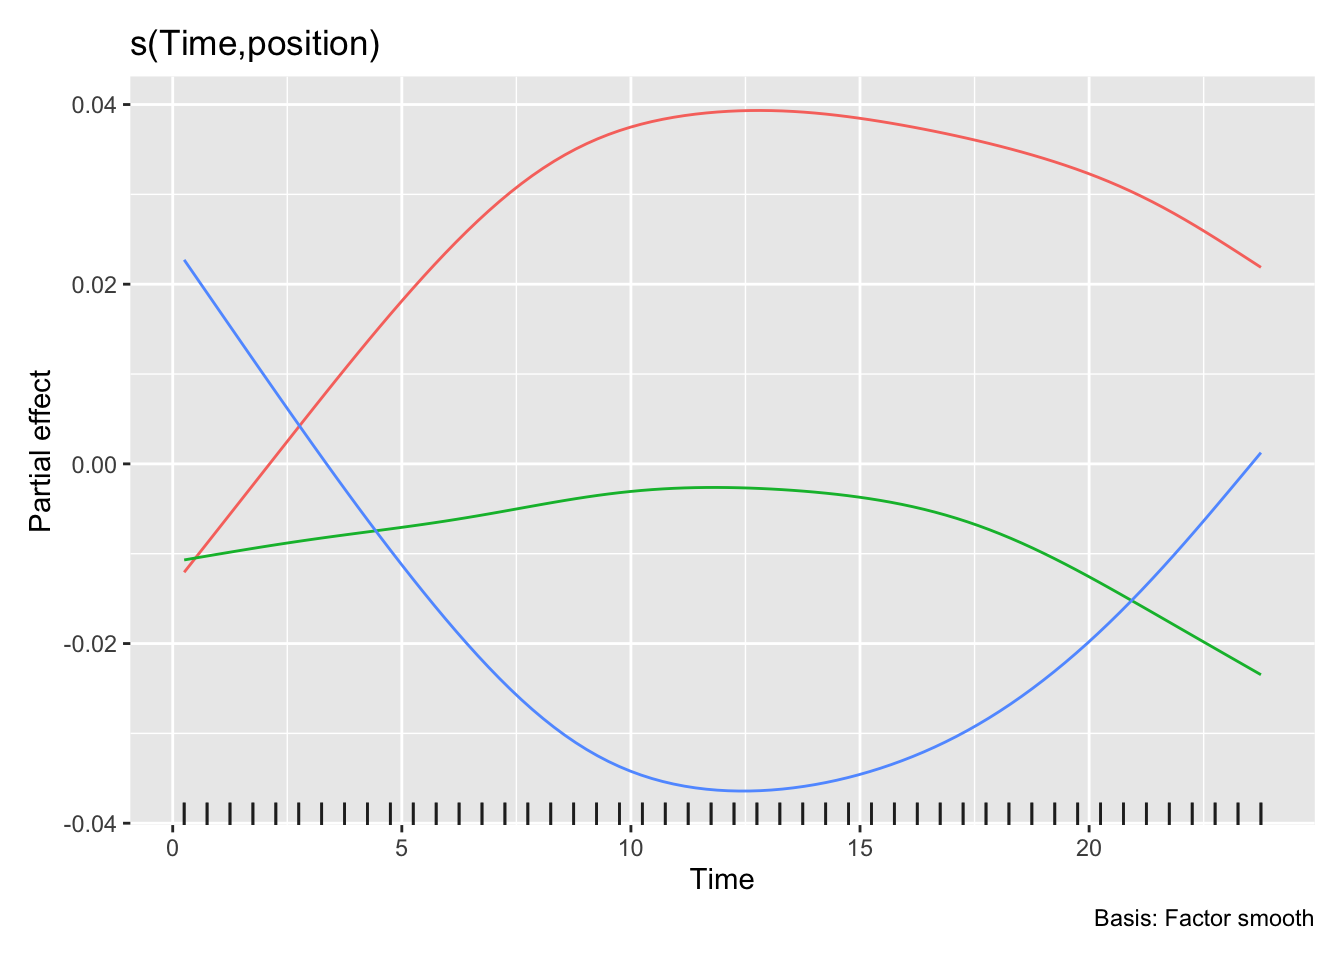

In [ ]:
model_1 <- 
  bam(formula_1, 
      data = time_data, 
      discrete = TRUE,
      method = "fREML",
      nthreads = 10
      )

r1 <- start_value_rho(model_1, 
                      plot=TRUE)


In [ ]:
Xp <- predict(model_1, type = "terms")
variance <- apply(Xp, 2, var)
cor(Xp)


                      s(Time) s(Time,position)  s(Time,site)    s(Time,Id)
s(Time)          1.0000000000     0.0024085317  0.0234343269  0.0240301756
s(Time,position) 0.0024085317     1.0000000000 -0.0000526665 -0.0005648307
s(Time,site)     0.0234343269    -0.0000526665  1.0000000000  0.0749064699
s(Time,Id)       0.0240301756    -0.0005648307  0.0749064699  1.0000000000
s(Id_date)       0.0001209681    -0.0019297974  0.0001878901  0.1063949196
                    s(Id_date)
s(Time)           0.0001209681
s(Time,position) -0.0019297974
s(Time,site)      0.0001878901
s(Time,Id)        0.1063949196
s(Id_date)        1.0000000000

# A tibble: 5 × 2
  parameter              R2
  <chr>               <dbl>
1 s(Time)          0.818   
2 s(Time,position) 0.000317
3 s(Time,site)     0.0510  
4 s(Time,Id)       0.103   
5 s(Id_date)       0.0279  

#### Null model (H11_0)

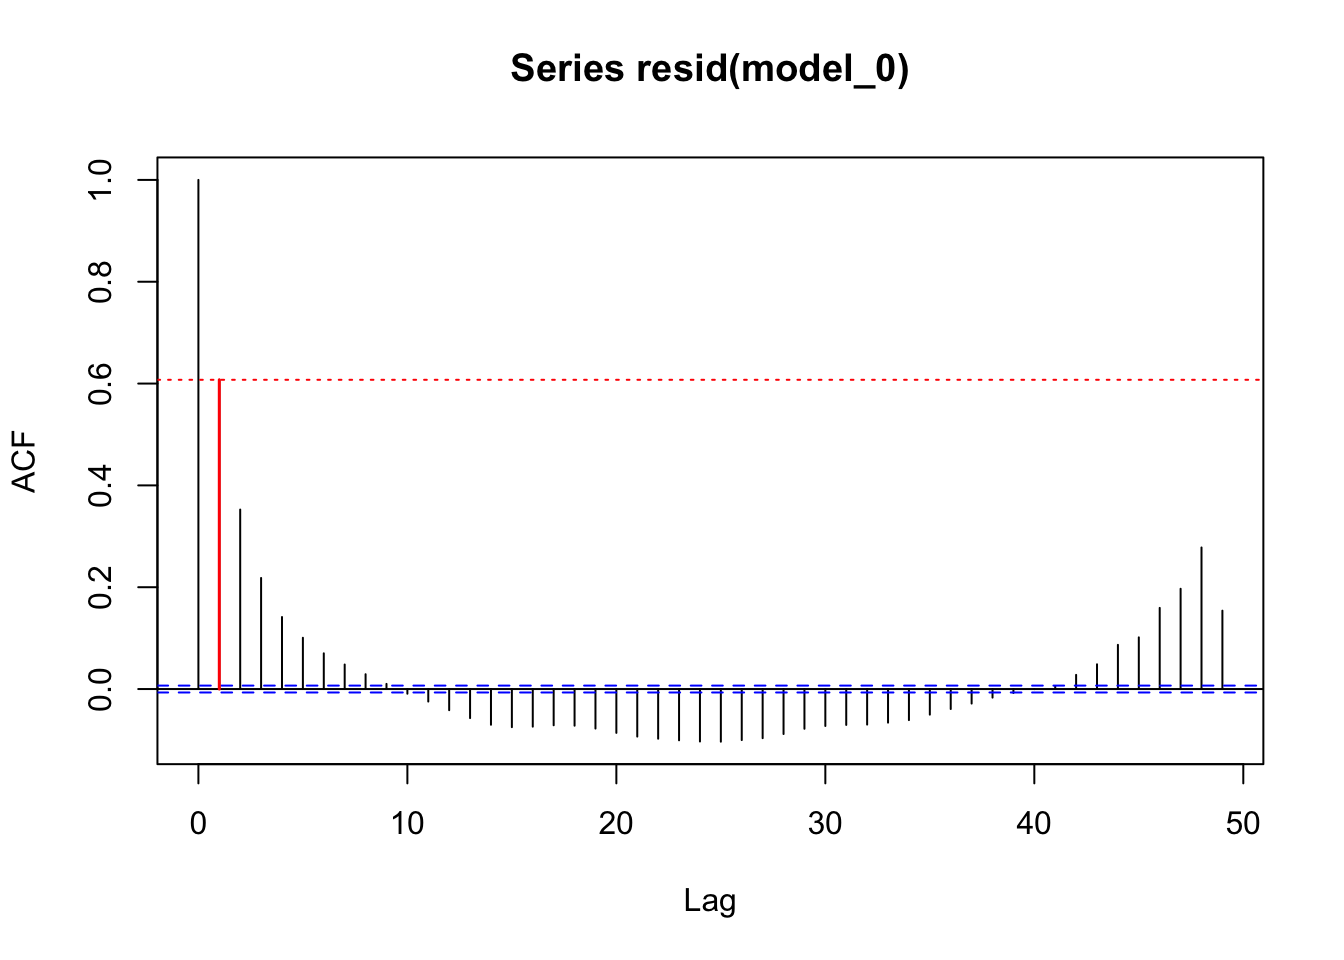

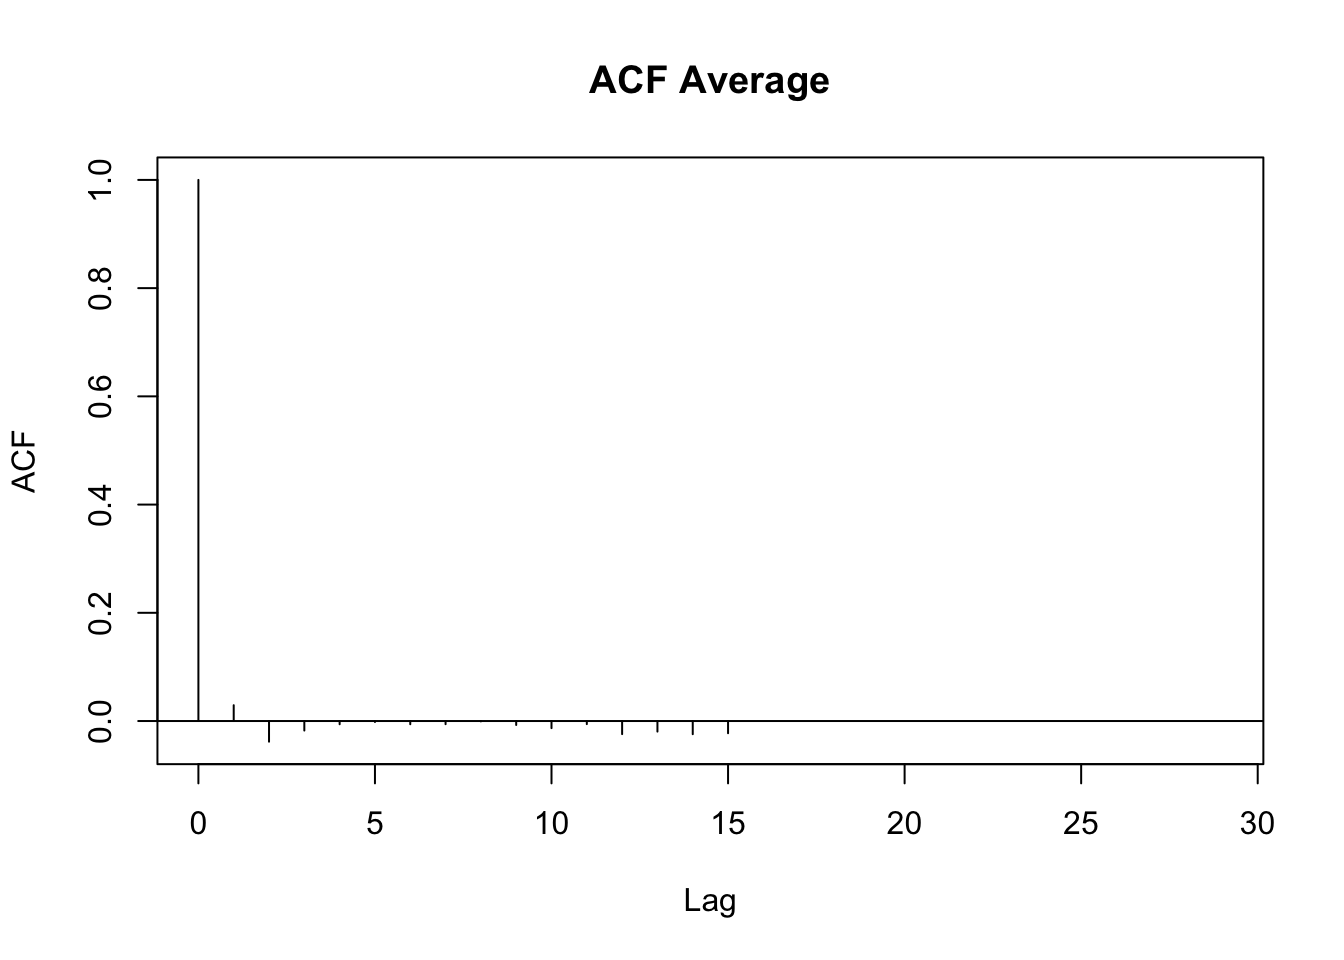


Family: gaussian 
Link function: identity 

Formula:
lzMEDI ~ s(Time, k = 12) + s(Time, site, bs = "sz", k = 12) + 
    s(Time, Id, bs = "fs") + s(Id_date, bs = "re")

Parametric coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.83513    0.02935   28.45   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                edf  Ref.df       F p-value    
s(Time)       10.83   10.89 194.115  <2e-16 ***
s(Time,site)  68.42   72.43   5.069  <2e-16 ***
s(Time,Id)   808.53 1044.00  14.401  <2e-16 ***
s(Id_date)   422.82  595.00   3.517  <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =   0.75   Deviance explained = 75.4%
fREML =  80369  Scale est. = 0.5999    n = 83946

# A tibble: 1 × 9
     df  logLik     AIC     BIC deviance df.residual  nobs adj.r.squared  npar
  <dbl>   <dbl>   <dbl>   <dbl>    <dbl>       <dbl> <int>         <dbl> <int>
1 1312. -77756. 158144. 170437.   50570.      82634. 83946         0.750  1758

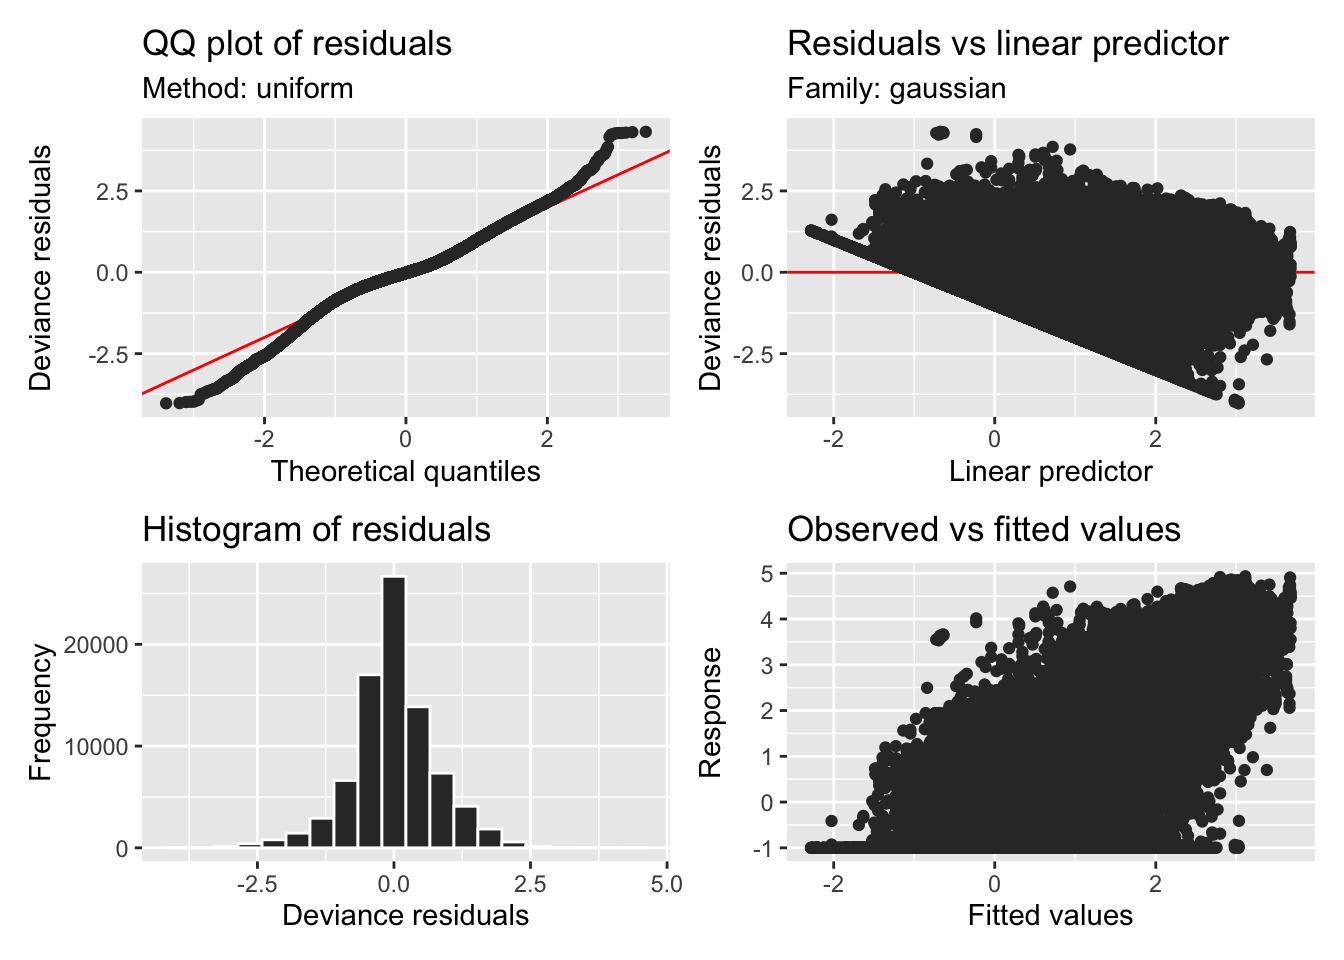

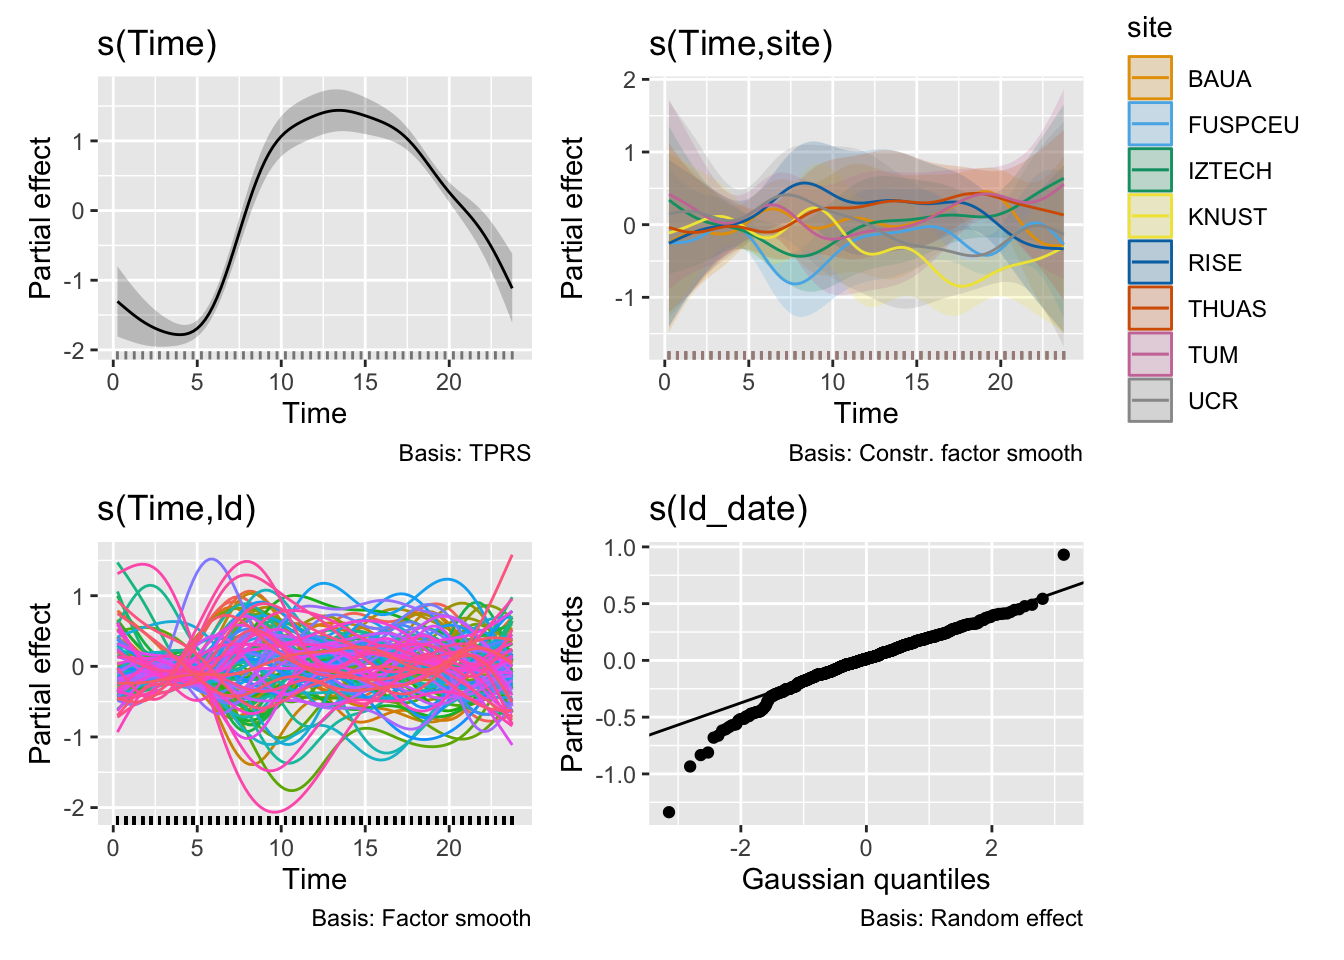

In [ ]:
model_0 <- 
  bam(formula_0, 
      data = time_data, 
      discrete = TRUE,
      method = "fREML",
      nthreads = 8
      )

r1 <- start_value_rho(model_0, 
                      plot=TRUE)


#### Model comparison

In [ ]:
AICs <- AIC(model_1, model_0)
AICs |> as_tibble(rownames = "model") |> gt()


> While position only explains very little of the overall structure (\<1% of variance explained), is has a ∆AIC \>2 and will thus be included

#### Model visualization

In [ ]:
model_data <- 
model_1 |> 
  conditional_values(
    condition = list(Time = seq(0.25, 23.75, by = 0.5), "position"),
    exclude = c("s(Time,site)", "s(Time,Id)", "s(Id_date)")
    ) |> 
  mutate(across(c(.fitted, .lower_ci, .upper_ci),
                exp_zero_inflated)
  )


Loading required package: legendry

Loading required package: ggtext

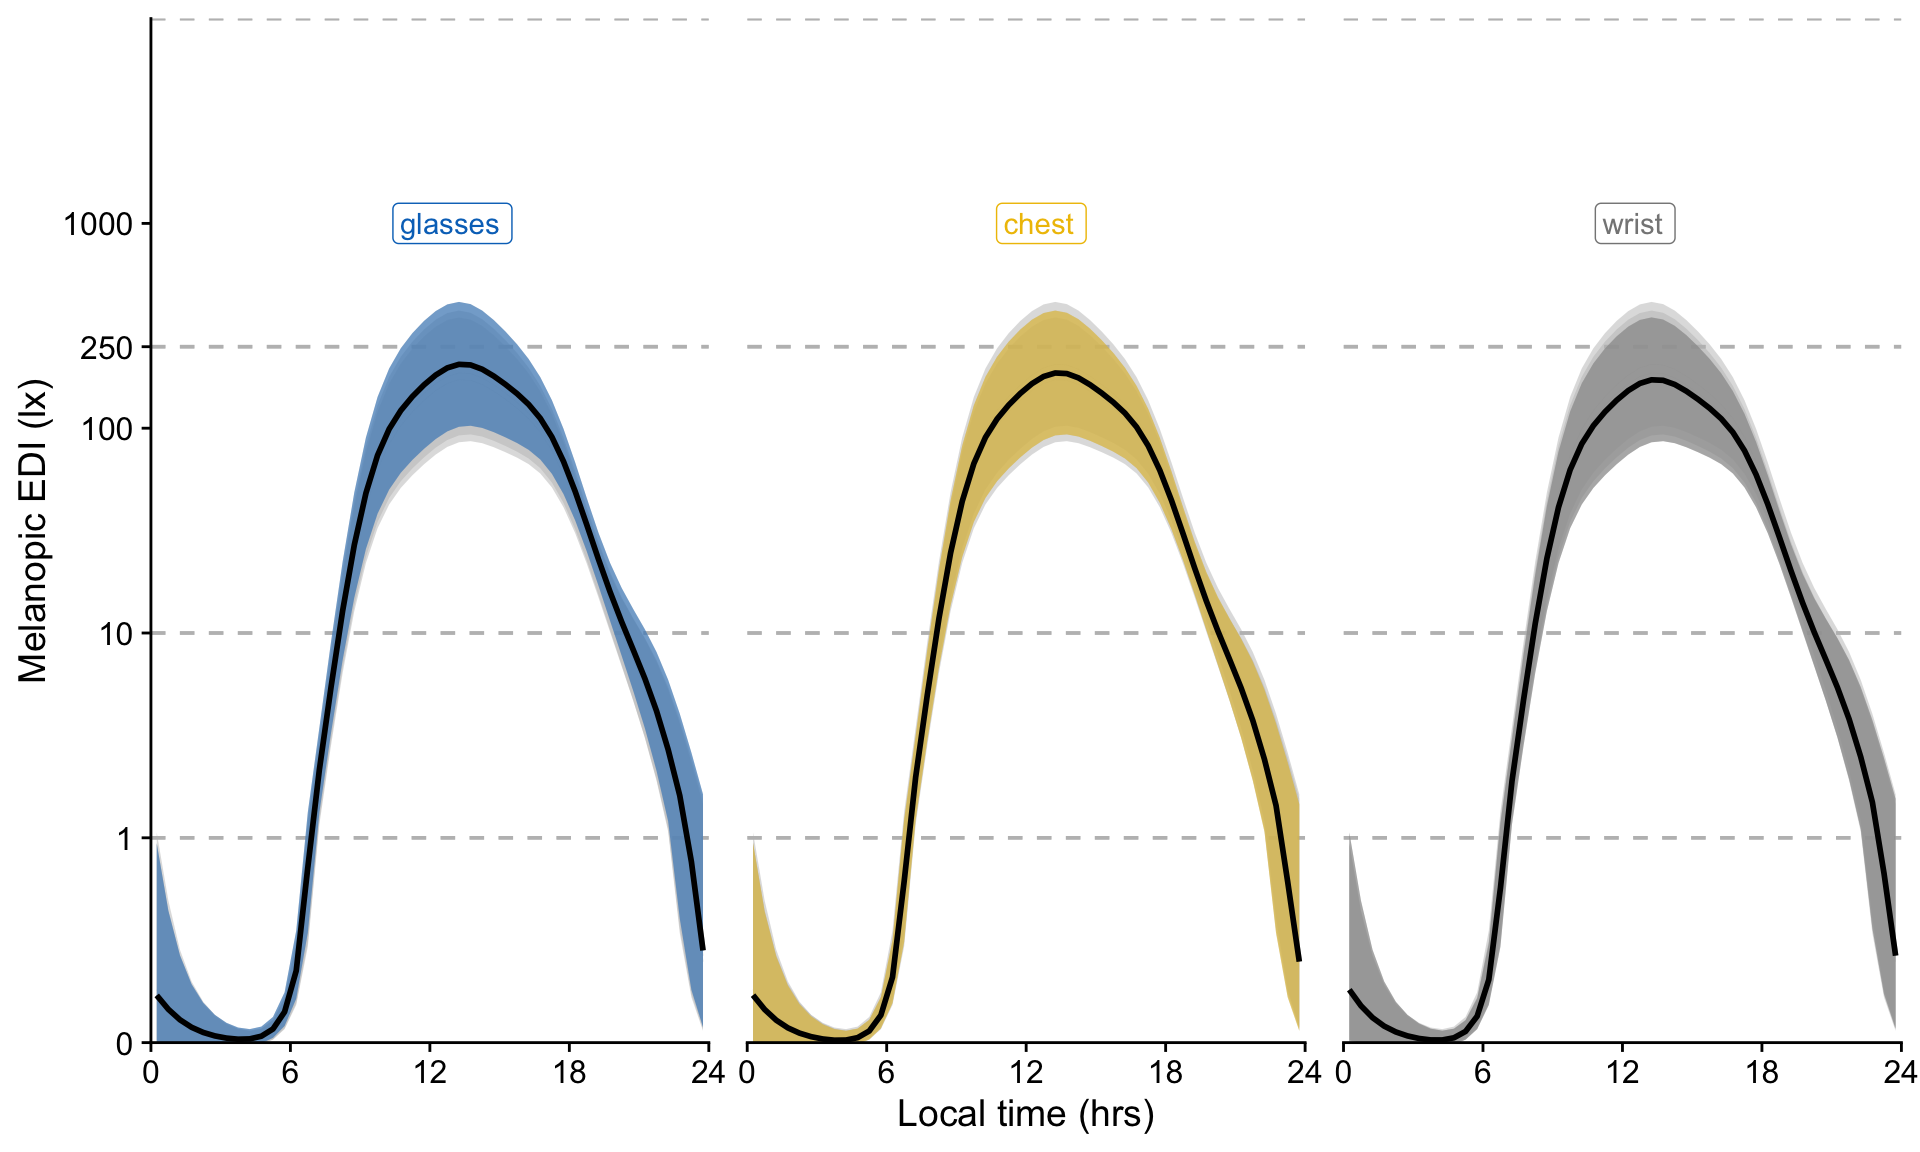

In [ ]:
source(here("scripts/Brown_bracket.R"))


In [ ]:
difference_sz <- function(model, data, x, fac, lev1, lev2,
                          sz_term,
                          exclude = NULL,
                          unconditional = FALSE,
                          level = 0.95) {

  data1 <- data
  data2 <- data

  fac_levels <- levels(model.frame(model)[[fac]])
  
  data1[[fac]] <- factor(rep(lev1, nrow(data1)), levels = fac_levels)
  
  data2[[fac]] <- factor(rep(lev2, nrow(data2)), levels = fac_levels)
  
  X1 <- predict(
    
    model, 
    newdata = data1,
    type = "lpmatrix",
    exclude = exclude,
    newdata.guaranteed = TRUE
  )

  X2 <- predict(
    model, 
    newdata = data2,
    type = "lpmatrix",
    exclude = exclude,
    newdata.guaranteed = TRUE
  )

  Xd <- X1 - X2

  ## keep only the sz smooth columns
  sm_labels <- vapply(model$smooth, `[[`, character(1), "label")
  i <- match(sz_term, sm_labels)

  if (is.na(i)) {
    stop(
      "Smooth not found. Available smooth labels are:\n",
      paste(sm_labels, collapse = "\n")
    )
  }

  keep <- model$smooth[[i]]$first.para:model$smooth[[i]]$last.para
  Xd[, setdiff(seq_len(ncol(Xd)), keep)] <- 0

  beta <- coef(model)
  V <- vcov(model, unconditional = unconditional)

  fit <- drop(Xd %*% beta)
  se <- sqrt(rowSums((Xd %*% V) * Xd))

  crit <- qnorm(1 - (1 - level) / 2)

  tibble(
    {{ x }} := data[[x]],
    comparison = paste0(lev1, "_", lev2),
    diff = fit,
    se = se,
    lower = fit - crit * se,
    upper = fit + crit * se
  )
}


In [ ]:
df <- model_1$model |> distinct(Time, .keep_all = TRUE)

model_comparison <- 
rbind(
difference_sz(model_1, df, "Time", "position", "chest", "glasses",
              "s(Time,position)",
              exclude = c("s(Time,site)", "s(Time,Id)", "s(Id_date)"),
              unconditional = FALSE,
              level = 0.95
),
difference_sz(model_1, df, "Time", "position", "wrist", "glasses", 
              "s(Time,position)",
              exclude = c("s(Time,site)", "s(Time,Id)", "s(Id_date)"),
              unconditional = FALSE,
              level = 0.95
)
) |> 
  mutate(position = str_remove(comparison, "_glasses"))


In [ ]:
model_terms <-
model_comparison |> 
  mutate(
         signif = lower > 0 | upper < 0,
         signif_id = consecutive_id(signif),
         .by = comparison) |> 
  ggplot(aes()) +
  map(c(log10(seq(0.8, 1.2, by = 0.1))),
      \(x) geom_hline(yintercept = x, linewidth = 0.5, col = "grey", linetype = 2)) +
  geom_ribbon(aes(x = Time, ymin = lower, ymax = upper, fill = position), alpha = 0.5) +
  geom_hline(yintercept = 0, linewidth = 1, linetype = 2) +
  geom_line(aes(x = Time, y = diff), 
            linewidth = 1) +
  geom_line(data = \(x) filter(x, signif),
            aes(x = Time, y = diff, group = signif_id), 
            col = "red", linewidth = 1) +
  # scale_color_manual(values = c(melidos_colors)) +
  theme_cowplot() +
  scale_fill_manual(values = colors[-1]) +
  scale_y_continuous(labels = c("-20%", "-10%", "±0%", "+10%", "+20%"),
                     breaks = log10(seq(0.80, 1.20, by = 0.1)))+
  scale_x_continuous(breaks = seq(0, 24, by = 6)) +
  coord_cartesian(xlim = c(0,24), expand = FALSE) +
  guides(fill = "none") +
  labs(y = "Factor", x = "Local time (hrs)", fill = "Position") +
  facet_wrap(~position) +
  theme(panel.spacing = unit(1, "lines"),
        plot.caption = element_textbox_simple(),
        legend.position = "bottom")


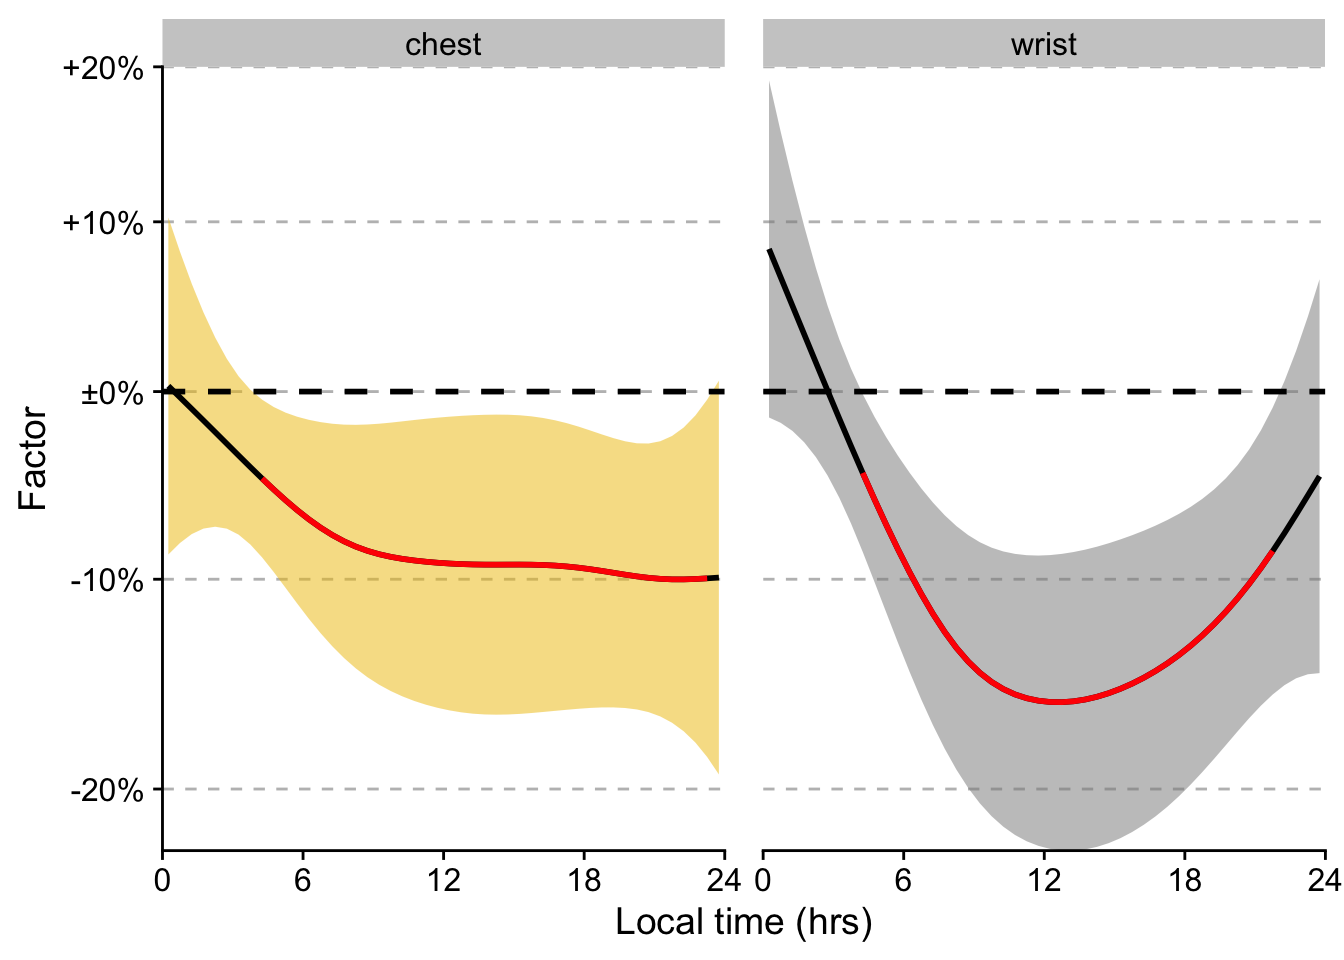

Saving 7 x 5 in image

In [ ]:
model_terms


### Interpretation

- There are significant differences between glasses and chest in the afternoon, growing larger towards the evening in the 8 to 10% range. There are significant differences between glasses and wrist during most waking hours and in the 8 to 15% range. Both chest and wrist tend to underestimate the glasses position.

## Session Info

In [ ]:
sessionInfo()


R version 4.5.0 (2025-04-11)
Platform: aarch64-apple-darwin20
Running under: macOS 26.3.1

Matrix products: default
BLAS:   /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.0.dylib 
LAPACK: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRlapack.dylib;  LAPACK version 3.12.1

locale:
[1] en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/en_US.UTF-8

time zone: Europe/Berlin
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices datasets  utils     methods   base     

other attached packages:
 [1] ggtext_0.1.2      legendry_0.2.4    gt_1.3.0          ggsci_5.0.0      
 [5] gghighlight_0.5.0 cowplot_1.2.0     itsadug_2.5       plotfunctions_1.5
 [9] broom_1.0.12      gratia_0.11.2     here_1.0.2        LightLogR_0.10.0 
[13] mgcv_1.9-4        nlme_3.1-169      lubridate_1.9.5   forcats_1.0.1    
[17] stringr_1.6.0     dplyr_1.2.1       purrr_1.2.2       readr_2.2.0      
[21] tidyr_1.3.2       tibble_3.3.1      ggp